In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor, BaggingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report ,mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

import warnings
warnings.filterwarnings('ignore')

In [53]:
import os
os.getcwd()

'/Users/bao/Documents/pulse-predictor-automator'

In [54]:
df = pd.read_csv('Data/HeartDisease.csv')
df.head()

,Age,Sex,ChestPainType,MaxHeartRate,ExerciseInducedAngina,HeartDisease
0,63,1,0,150,0,No
1,67,1,3,108,1,Yes
2,67,1,3,129,1,Yes
3,37,1,2,187,0,No
4,41,0,1,172,0,No


In [55]:
df.shape

(303, 6)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Age                    303 non-null    int64
 1   Sex                    303 non-null    int64
 2   ChestPainType          303 non-null    int64
 3   MaxHeartRate           303 non-null    int64
 4   ExerciseInducedAngina  303 non-null    int64
 5   HeartDisease           303 non-null    str  
dtypes: int64(5), str(1)
memory usage: 14.3 KB


In [57]:
missing_vals = df.isnull().sum()
missing_pct = (missing_vals / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_vals, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [58]:
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicate_count}")


Number of duplicate records: 0


In [59]:
numerical_cols = ['Age', 'MaxHeartRate']
categorical_cols = ['Sex', 'ChestPainType', 'ExerciseInducedAngina']

In [60]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'MaxHeartRate', 'ExerciseInducedAngina',
       'HeartDisease'],
      dtype='str')

In [61]:
X = df.drop(['HeartDisease'], axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [62]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [75]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


transform = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), categorical_cols),
        ("num", num_transformer, numerical_cols)
    ]
)

svm_pipeline = Pipeline(
    steps=[
        ("preprocessing", transform),
        ("model", SVC(probability=True, class_weight='balanced', random_state=42))
    ]
)

param_grid_svm = {
    "model__kernel": ["linear", "rbf", "poly"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"],
    "model__degree": [2, 3]  # only used for 'poly'
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# Fit GridSearch
grid_svm.fit(X_train, y_train)

cal_svm = CalibratedClassifierCV(estimator=grid_svm.best_estimator_, cv=cv)
cal_svm.fit(X_train, y_train)

# Predict
y_pred_svm = cal_svm.predict(X_test)


print("Best SVM Parameters:", grid_svm.best_params_)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Best SVM Parameters: {'model__C': 0.1, 'model__degree': 2, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Classification Report:

              precision    recall  f1-score   support

          No       0.85      0.88      0.87        33
         Yes       0.85      0.82      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [76]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm, average="macro")

print("Accuracy:", str(round(accuracy, 2) * 100) + "%", "F1:", round(f1, 2))


Accuracy: 85.0% F1: 0.85


In [77]:
with open("Results/metrics.txt", "w") as outfile:
    outfile.write(f"\nAccuracy = {accuracy}, F1 Score = {f1}.")

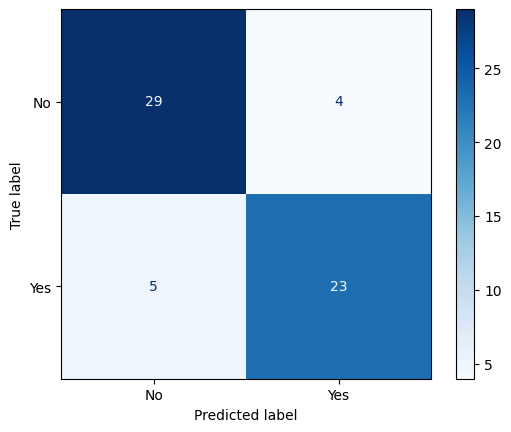

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

classes = cal_svm.classes_

cm = confusion_matrix(y_test, y_pred_svm, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues) 

plt.savefig("Results/model_results.png", dpi=120)
plt.show()

In [ ]:
import skops.io as sio

# Save your pipeline
sio.dump(svm_pipeline, "Model/pulse_pipeline.skops")

# Load safely (trusted must be a list of types used in your pipeline)
trusted_types = [
    "sklearn.pipeline.Pipeline",
    "sklearn.preprocessing._data.StandardScaler",
    "sklearn.svm._classes.SVC"
]

sio.load("Model/pulse_pipeline.skops", trusted=trusted_types)